# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [39]:
import pandas as pd

df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


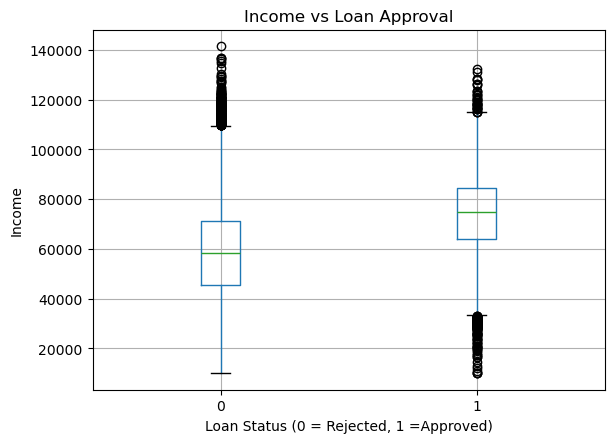

In [40]:
import matplotlib.pyplot as plt

df.boxplot(column='person_income', by='loan_status')
plt.title('Income vs Loan Approval')
plt.suptitle('')
plt.xlabel('Loan Status (0 = Rejected, 1 =Approved)')
plt.ylabel('Income')
plt.grid(True)
plt.show()

### Income vs Loan Approval
The boxplot shows that approved applicants (1) generally have a higher income than rejected applicants (0). While there are many outliers in both groups, the median income for approved individuals is noticeably higher, indicating that income is an important factor influencing the model's decision. 

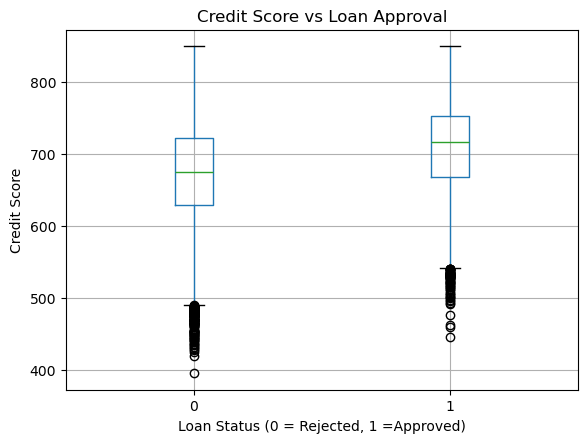

In [41]:
df.boxplot(column='credit_score', by='loan_status')
plt.title('Credit Score vs Loan Approval')
plt.suptitle('')
plt.xlabel('Loan Status (0 = Rejected, 1 =Approved)')
plt.ylabel('Credit Score')
plt.grid(True)
plt.show()

 ### Credit Score vs Loan Approval
The boxplot shows a clear difference in credit scores between approved (1) and rejected (0) applicants. Approved individuals have a noticeably higher median credit score compared to rejected individuals. This indicates that credit score is a strong factor influencing the model’s decision, with higher credit scores increasing the likelihood of loan approval.

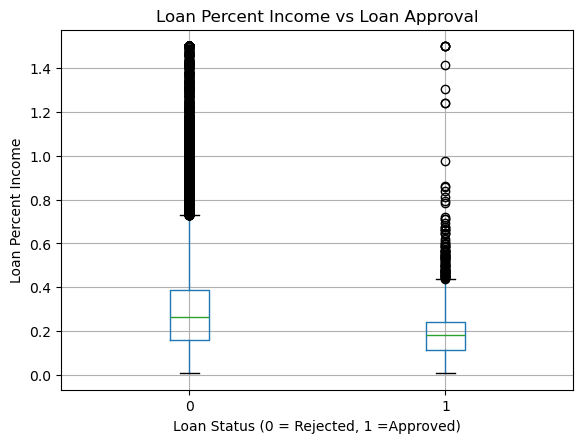

In [42]:
df.boxplot(column='loan_percent_income', by='loan_status')
plt.title('Loan Percent Income vs Loan Approval')
plt.suptitle('')
plt.xlabel('Loan Status (0 = Rejected, 1 =Approved)')
plt.ylabel('Loan Percent Income')
plt.grid(True)
plt.show()

### Loan Percent Income vs Loan Approval
The boxplot shows that rejected applicants (0) tend to have higher loan-to-income ratios compared to approved applicants (1). The median loan percent income is noticeably higher for rejected individuals, indicating that applicants requesting loans that make up a larger portion of their income are more likely to be denied. This suggests that the model considers financial burden as an important factor in its decision-making process.

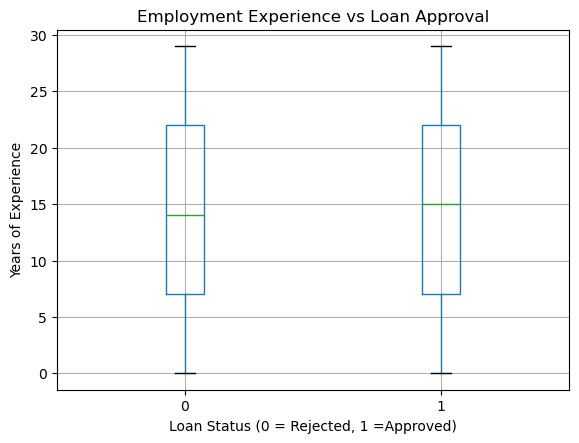

In [43]:
df.boxplot(column='person_emp_exp', by='loan_status')
plt.title('Employment Experience vs Loan Approval')
plt.suptitle('')
plt.xlabel('Loan Status (0 = Rejected, 1 =Approved)')
plt.ylabel('Years of Experience')
plt.grid(True)
plt.show()

### Employment Experience vs Loan Approval
The boxplot shows significant overlap between approved (1) and rejected (0) applicants in terms of employment experience. The median values are very similar, and there is no clear separation between the two groups. This suggests that employment experience is not a strong factor influencing the model’s decision.

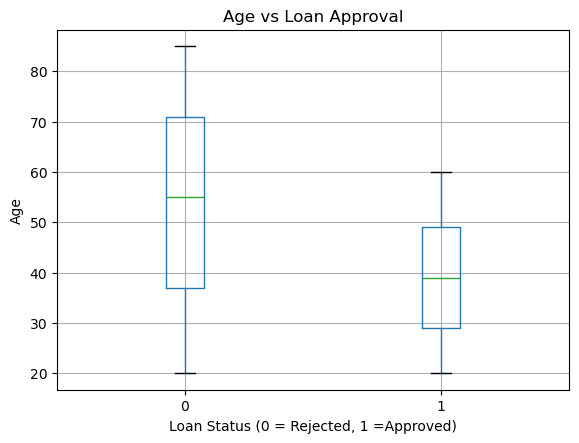

In [44]:
df.boxplot(column='person_age', by='loan_status')
plt.title('Age vs Loan Approval')
plt.suptitle('')
plt.xlabel('Loan Status (0 = Rejected, 1 =Approved)')
plt.ylabel('Age')
plt.grid(True)
plt.show()

### Age vs Loan Approval
The boxplot shows that approved applicants (1) tend to be younger than rejected applicants (0). The median age for rejected individuals is noticeably higher, indicating that older applicants are more likely to be denied. This suggests that age may influence the model’s decision, with younger applicants having a higher likelihood of approval.

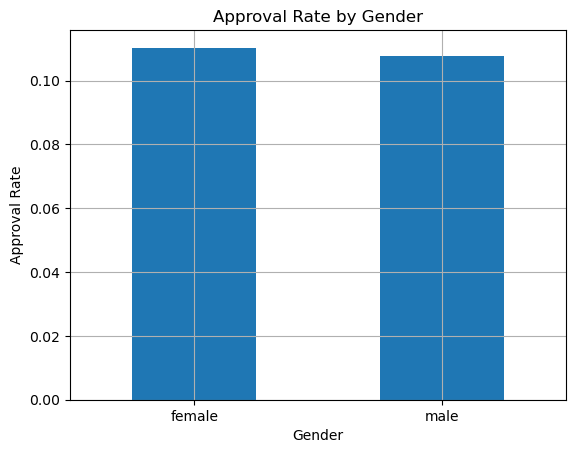

In [45]:
df.groupby('person_gender')['loan_status'].mean().plot(kind='bar')
plt.title('Approval Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Approval Rate')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

### Approval Rate by Gender
The bar chart shows that approval rates for male and female applicants are nearly identical, both around 10–11%. There is no significant difference between the two groups, suggesting that gender does not appear to strongly influence the model’s decision. This indicates that the model is likely not biased based on gender.

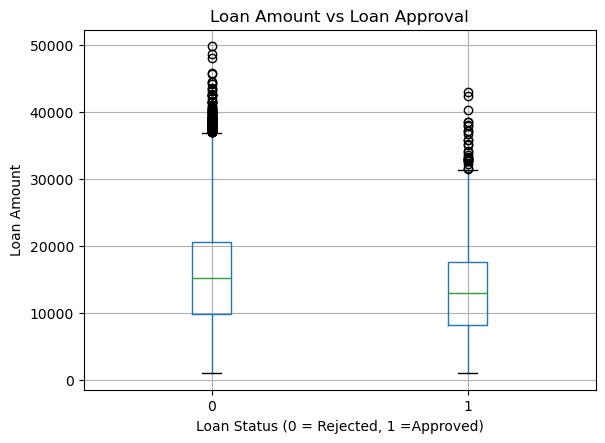

In [46]:
df.boxplot(column='loan_amnt', by='loan_status')
plt.title('Loan Amount vs Loan Approval')
plt.suptitle('')
plt.xlabel('Loan Status (0 = Rejected, 1 =Approved)')
plt.ylabel('Loan Amount')
plt.grid(True)
plt.show()

### Loan Amount vs Loan Approval
The boxplot shows that there is a lot of overlap between approved (1) and rejected (0) applicants in terms of loan amount. The median values are fairly similar, and there is no clear separation between the two groups. This suggests that loan amount is not a strong factor influencing the model’s decision.

### Final Analysis
Based on the visualizations, the features that most strongly influence the model’s decision to approve a loan are credit score and loan percent income. Applicants with higher credit scores are much more likely to be approved, while those requesting loans that take up a larger portion of their income are more likely to be rejected.

Income also plays a role, as approved applicants generally have higher incomes, but it is not as strong of a factor as credit score or loan percent income. Employment experience does not appear to have a strong impact, since there is a lot of overlap between approved and rejected applicants. Loan amount does not appear to strongly influence the model's decision, as there is significant overlap between approved and rejected applicants.

Gender does not show any meaningful difference in approval rates, which suggests the model is not biased based on gender.

However, age does appear to influence the model’s decision. Younger applicants are more likely to be approved, while older applicants are more likely to be rejected. Since age is a sensitive attribute, this could raise concerns about potential bias and legal issues. The financial institution should further investigate how age is being used to ensure fairness and avoid discrimination in the decision process.